In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
print("hello world!")

hello world!


# MODIS Ocean Data Exploaration 

Following example from https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/modis-explore-l3/

In [3]:
from matplotlib import pyplot as plt
import cartopy
import earthaccess
import numpy as np
import xarray as xr

In [15]:
auth = earthaccess.login(persist=True)

In [5]:
results = earthaccess.search_datasets(
    keyword="L3m ocean color modis aqua chlorophyll",
    instrument = "MODIS",
)
len(results)

3

In [6]:
set((i.summary()["short-name"] for i in results))


{'MODISA_L3m_CHL', 'MODISA_L3m_CHL_NRT', 'MODIST_L3m_CHL'}

In [7]:
tspan = ("2016-09-20", "2016-09-20")
results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    temporal=tspan,
)

In [8]:
results[0]


Collection: {'ShortName': 'MODISA_L3m_CHL', 'Version': '2022.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'EastBoundingCoordinate': 180, 'SouthBoundingCoordinate': -90, 'WestBoundingCoordinate': -180, 'NorthBoundingCoordinate': 90}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-02-28T23:59:59Z', 'BeginningDateTime': '2002-07-04T00:00:00Z'}}
Size(MB): 15.967497825622559
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20020704_20250228.L3m.CU.CHL.chlor_a.9km.nc']

In [9]:
results[0].cloud_hosted

True

In [10]:
# use only for initial download
# paths = earthaccess.download(results, "modis_data") 
paths = ['modis_data/AQUA_MODIS.20020704_20250228.L3m.CU.CHL.chlor_a.9km.nc']

In [11]:
dataset = xr.open_dataset(paths[0])
dataset

<xarray.Dataset> Size: 37MB
Dimensions:  (lat: 2160, lon: 4320, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 9kB 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 37MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      AQUA_MODIS.20020704_20250228.L3m.CU.CH...
    instrument:                        MODIS
    title:                             MODISA Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          Aqua
    source:                            satellite observations from MODIS-Aqua
    ...                                ...
    identifier_product_doi:            10.5067/AQUA/MODIS/L3M/CHL/2022
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         5840616
    data_minimum:                      0.0016383681
    data_maximum:                      85.59566

# Plot the Data

In [12]:
array = np.log10(dataset["chlor_a"])
array.attrs.update(
    {
        "units": f'log10({dataset["chlor_a"].attrs["units"]})',
    }
)
crs_proj = cartopy.crs.Robinson()
crs_data = cartopy.crs.PlateCarree()

Text(0.5, 1.0, 'AQUA_MODIS.20020704_20250228.L3m.CU.CHL.chlor_a.9km.nc')

/home/dhan/code/misc/streamlit_tutorial/myenv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


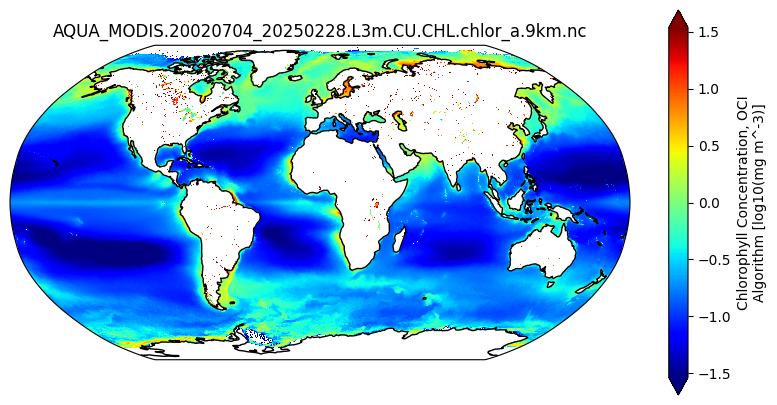

In [13]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(projection=crs_proj)
array.plot(x="lon", y="lat", cmap="jet", ax=ax, robust=True, transform=crs_data)
ax.coastlines()
ax.set_title(dataset.attrs["product_name"])
plt.show()

In [17]:
tspan = ("2022-09-20", "2023-09-20")
results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    granule_name="*.8D*.9km*",
    temporal=tspan,
)

In [19]:
len(results)

47

In [20]:
results[0]

Collection: {'ShortName': 'MODISA_L3m_CHL', 'Version': '2022.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'NorthBoundingCoordinate': 90, 'EastBoundingCoordinate': 180, 'WestBoundingCoordinate': -180, 'SouthBoundingCoordinate': -90}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2022-09-14T00:00:00Z', 'EndingDateTime': '2022-09-21T23:59:59Z'}}
Size(MB): 12.31857681274414
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20220914_20220921.L3m.8D.CHL.chlor_a.9km.nc']

# Download all the Daily Aqua Data from Terra Satellite


In [23]:
import os
for year in range(2002, 2026):
    folder = f"MODIS_AQUA_L3m_CHL_8D_9km/{year}"
    os.makedirs(folder, exist_ok=True)
    tspan = (f"{year}-01-01", f"{year}-12-31")
    results = earthaccess.search_data(
        short_name="MODISA_L3m_CHL",
        granule_name="*.8D*.9km*",
        temporal=tspan,
    )
    # Download each result into the specific folder
    for granule in results:
        earthaccess.download(granule, folder)
        print("Completed downloading 

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

['MODIS_AQUA_L3m_CHL_8D_9km/2002/AQUA_MODIS.20020704_20020711.L3m.8D.CHL.chlor_a.9km.nc']

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

['MODIS_AQUA_L3m_CHL_8D_9km/2025/AQUA_MODIS.20250712_20250719.L3m.8D.CHL.chlor_a.9km.nc']

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

['MODIS_AQUA_L3m_CHL_8D_9km/2025/AQUA_MODIS.20250720_20250727.L3m.8D.CHL.chlor_a.9km.nc']